In [1]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [2]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_qtcheck.xlsx")
num_desc = pd.read_excel("local_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("local_categorical_qtcheck.xlsx", index_col=0)


In [3]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   기준년월          6240 non-null   category
 1   행정동코드         6240 non-null   int64   
 2   매출금액          6240 non-null   int64   
 3   행정구역          6240 non-null   str     
 4   총인구수          6240 non-null   int64   
 5   월유동인구수        6240 non-null   float64 
 6   년도            6240 non-null   category
 7   가맹점수_소매       6240 non-null   int64   
 8   가맹점수_숙박       6240 non-null   int64   
 9   가맹점수_음식       6240 non-null   int64   
 10  가맹점수_부동산      6240 non-null   int64   
 11  가맹점수_과학·기술    6240 non-null   int64   
 12  가맹점수_시설관리·임대  6240 non-null   int64   
 13  가맹점수_교육       6240 non-null   int64   
 14  가맹점수_보건의료     6240 non-null   int64   
 15  가맹점수_예술·스포츠   6240 non-null   int64   
 16  가맹점수_수리·개인    6240 non-null   int64   
 17  가맹점수_기타       6240 non-null   int64   
dtypes: category(2), flo

In [4]:
# 위경도 데이터 불러오기
coord = pd.read_csv(
    "경기도_행정동_중심점.csv",
    encoding="utf-8",
    dtype={"ADM_CD": str}
)

coord.head()

,X,Y,BASE_DATE,ADM_CD,ADM_NM
0,126.989378,37.320531,20250630,31011540,파장동
1,126.971753,37.299592,20250630,31011550,율천동
2,126.989323,37.304703,20250630,31011560,정자1동
3,126.998383,37.292271,20250630,31011570,정자2동
4,127.013579,37.291219,20250630,31011580,영화동


In [5]:
# 위경도 데이터 불러오기
df_area = pd.read_excel(
    "local_data.xlsx"
)

df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,교육_비율,보건의료_비율,예술·스포츠_비율,수리·개인_비율,기타_비율,TOP3_업종,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,0.042523,0.030100,0.032489,0.128046,0.028667,"['소매_비율', '음식_비율', '수리·개인_비율']",10.071444,2.309790e+06,697.666667,285.001345
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,0.104567,0.025541,0.061899,0.145132,0.028245,"['음식_비율', '소매_비율', '수리·개인_비율']",13.170850,6.843445e+06,1109.333333,276.350848
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,0.186441,0.040832,0.035439,0.131741,0.030046,"['소매_비율', '음식_비율', '교육_비율']",11.499619,4.337255e+06,432.666667,139.358794
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,0.065684,0.030831,0.029044,0.172922,0.030831,"['소매_비율', '음식_비율', '수리·개인_비율']",35.018519,4.340631e+06,746.000000,196.425633
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,0.219847,0.042757,0.051053,0.118698,0.018826,"['음식_비율', '소매_비율', '교육_비율']",17.808357,1.385744e+07,1044.666667,266.079153


In [6]:
# 위경도 데이터 불러오기
code = pd.read_excel(
    "adm_code.xls"
)

code.head()

,2025년6월 행정구역 코드,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,시도코드,시도명칭,시군구코드,시군구명칭,읍면동코드,읍면동명칭
1,11,서울특별시,010,종로구,530,사직동
2,11,서울특별시,010,종로구,540,삼청동
3,11,서울특별시,010,종로구,550,부암동
4,11,서울특별시,010,종로구,560,평창동


In [7]:
# 1. 첫 번째 행을 컬럼명으로 지정
code_map = code.copy()
code_map.columns = code_map.iloc[0].astype(str).str.strip()
code_map = code_map.iloc[1:].reset_index(drop=True)

# 2. 경기도만 추출
code_map = code_map[
    code_map["시도명칭"].astype(str).str.strip() == "경기도"
].copy()

# 3. 코드 자릿수를 맞춰 SGIS 코드 생성
for col, width in [
    ("시도코드", 2),
    ("시군구코드", 3),
    ("읍면동코드", 3)
]:
    code_map[col] = (
        code_map[col].astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )

code_map["ADM_CD"] = (
    code_map["시도코드"]
    + code_map["시군구코드"]
    + code_map["읍면동코드"]
)

# 4. 전체 행정구역명 생성
code_map["행정구역"] = (
    code_map["시도명칭"].str.strip() + " "
    + code_map["시군구명칭"].str.strip() + " "
    + code_map["읍면동명칭"].str.strip()
)

# 5. 좌표 데이터에 전체 행정구역명 연결
coord_named = coord.copy()
coord_named["ADM_CD"] = (
    coord_named["ADM_CD"].astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)

coord_named = coord_named.merge(
    code_map[["ADM_CD", "행정구역"]],
    on="ADM_CD",
    how="left",
    validate="one_to_one"
)

# 코드표와 연결되지 않은 좌표 확인
display(
    coord_named.loc[
        coord_named["행정구역"].isna(),
        ["ADM_CD", "ADM_NM"]
    ]
)

,ADM_CD,ADM_NM


In [8]:
# 6. 병합용 이름 정리
area = df_area.copy()
area["_지역키"] = area["행정구역"].str.replace(r"\s+", "", regex=True)

coord_named["_지역키"] = (
    coord_named["행정구역"].str.replace(r"\s+", "", regex=True)
)

lookup = (
    coord_named.dropna(subset=["_지역키"])
    [["_지역키", "Y", "X"]]
    .rename(columns={"Y": "위도", "X": "경도"})
)

# 7. 위도·경도 추가 (재실행 시 기존 좌표 교체)
df_area_geo = (
    area.drop(columns=["위도", "경도"], errors="ignore")
    .merge(
        lookup,
        on="_지역키",
        how="left",
        validate="one_to_one"
    )
    .drop(columns="_지역키")
)

# 8. 연결되지 않은 지역 확인
missing = df_area_geo.loc[
    df_area_geo[["위도", "경도"]].isna().any(axis=1),
    ["행정동코드", "행정구역"]
]

print(f"전체 {len(df_area_geo)}개 중 좌표 미연결 {len(missing)}개")
display(missing)

전체 260개 중 좌표 미연결 0개


,행정동코드,행정구역


In [9]:
df_area = df_area_geo.copy()

In [10]:
df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,예술·스포츠_비율,수리·개인_비율,기타_비율,TOP3_업종,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수,위도,경도
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,0.032489,0.128046,0.028667,"['소매_비율', '음식_비율', '수리·개인_비율']",10.071444,2.309790e+06,697.666667,285.001345,37.320531,126.989378
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,0.061899,0.145132,0.028245,"['음식_비율', '소매_비율', '수리·개인_비율']",13.170850,6.843445e+06,1109.333333,276.350848,37.299592,126.971753
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,0.035439,0.131741,0.030046,"['소매_비율', '음식_비율', '교육_비율']",11.499619,4.337255e+06,432.666667,139.358794,37.304703,126.989323
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,0.029044,0.172922,0.030831,"['소매_비율', '음식_비율', '수리·개인_비율']",35.018519,4.340631e+06,746.000000,196.425633,37.292271,126.998383
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,0.051053,0.118698,0.018826,"['음식_비율', '소매_비율', '교육_비율']",17.808357,1.385744e+07,1044.666667,266.079153,37.298399,126.984661


In [11]:
print("전체 행 수:", len(df_area))
print("고유 행정동 수:", df_area["행정동코드"].nunique())
print("좌표 결측:")
print(df_area[["위도", "경도"]].isna().sum())

전체 행 수: 260
고유 행정동 수: 260
좌표 결측:
위도    0
경도    0
dtype: int64


In [12]:
# 서울까지의 거리 파생변수 생성
def distance_km(lat, lon, center_lat, center_lon):
    # 도 → 라디안 변환
    lat = np.radians(lat)
    lon = np.radians(lon)
    center_lat = np.radians(center_lat)
    center_lon = np.radians(center_lon)

    dlat = lat - center_lat
    dlon = lon - center_lon

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat) * np.cos(center_lat)
        * np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

In [13]:
# 서울 기준점까지의 직선거리(km)
df_area["서울중심지_거리_km"] = distance_km(
    lat=df_area["위도"],
    lon=df_area["경도"],
    center_lat=37.5666,
    center_lon=126.9784
)

# 결과 확인
df_area[
    ["행정구역", "위도", "경도", "서울중심지_거리_km"]
].head()

,행정구역,위도,경도,서울중심지_거리_km
0,경기도 수원시 장안구 파장동,37.320531,126.989378,27.378798
1,경기도 수원시 장안구 율천동,37.299592,126.971753,29.695822
2,경기도 수원시 장안구 정자1동,37.304703,126.989323,29.137576
3,경기도 수원시 장안구 정자2동,37.292271,126.998383,30.555018
4,경기도 수원시 장안구 정자3동,37.298399,126.984661,29.827806


In [14]:
df_area.to_excel("local_data2.xlsx", index=False)

In [16]:
df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,수리·개인_비율,기타_비율,TOP3_업종,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수,위도,경도,서울중심지_거리_km
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,0.128046,0.028667,"['소매_비율', '음식_비율', '수리·개인_비율']",10.071444,2.309790e+06,697.666667,285.001345,37.320531,126.989378,27.378798
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,0.145132,0.028245,"['음식_비율', '소매_비율', '수리·개인_비율']",13.170850,6.843445e+06,1109.333333,276.350848,37.299592,126.971753,29.695822
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,0.131741,0.030046,"['소매_비율', '음식_비율', '교육_비율']",11.499619,4.337255e+06,432.666667,139.358794,37.304703,126.989323,29.137576
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,0.172922,0.030831,"['소매_비율', '음식_비율', '수리·개인_비율']",35.018519,4.340631e+06,746.000000,196.425633,37.292271,126.998383,30.555018
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,0.118698,0.018826,"['음식_비율', '소매_비율', '교육_비율']",17.808357,1.385744e+07,1044.666667,266.079153,37.298399,126.984661,29.827806


In [17]:
column_means = {
    "매출금액": "지역화폐 매출",
    "행정동코드": "행정동코드",
    "총인구수": "총인구수",
    "월유동인구수": "월유동인구수",
    "가맹점수_소매": "가맹점수_소매",
    "가맹점수_숙박": "가맹점수_숙박",
    "가맹점수_음식": "가맹점수_음식",
    "가맹점수_부동산": "가맹점수_부동산",
    "가맹점수_과학·기술": "가맹점수_과학·기술",
    "가맹점수_시설관리·임대": "가맹점수_시설관리·임대",
    "가맹점수_교육": "가맹점수_교육",
    "가맹점수_보건의료": "가맹점수_보건의료",
    "가맹점수_예술·스포츠": "가맹점수_예술·스포츠",
    "가맹점수_수리·개인": "가맹점수_수리·개인",
    "가맹점수_기타": "가맹점수_기타",
    "기준년월": "기준년월",
    "년도": "년도",
    "위도": "위도",
    "경도": "경도",
    "서울중심지_거리_km": "서울까지거리",
    "1인당_유동인구": "1인당_유동인구",
    "만명당_가맹점수": "만명당_가맹점수"
}

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
위도                 36.98 ~ 37.95          -2.04 ~ 2.52
경도               126.59 ~ 127.65          -2.65 ~ 4.16


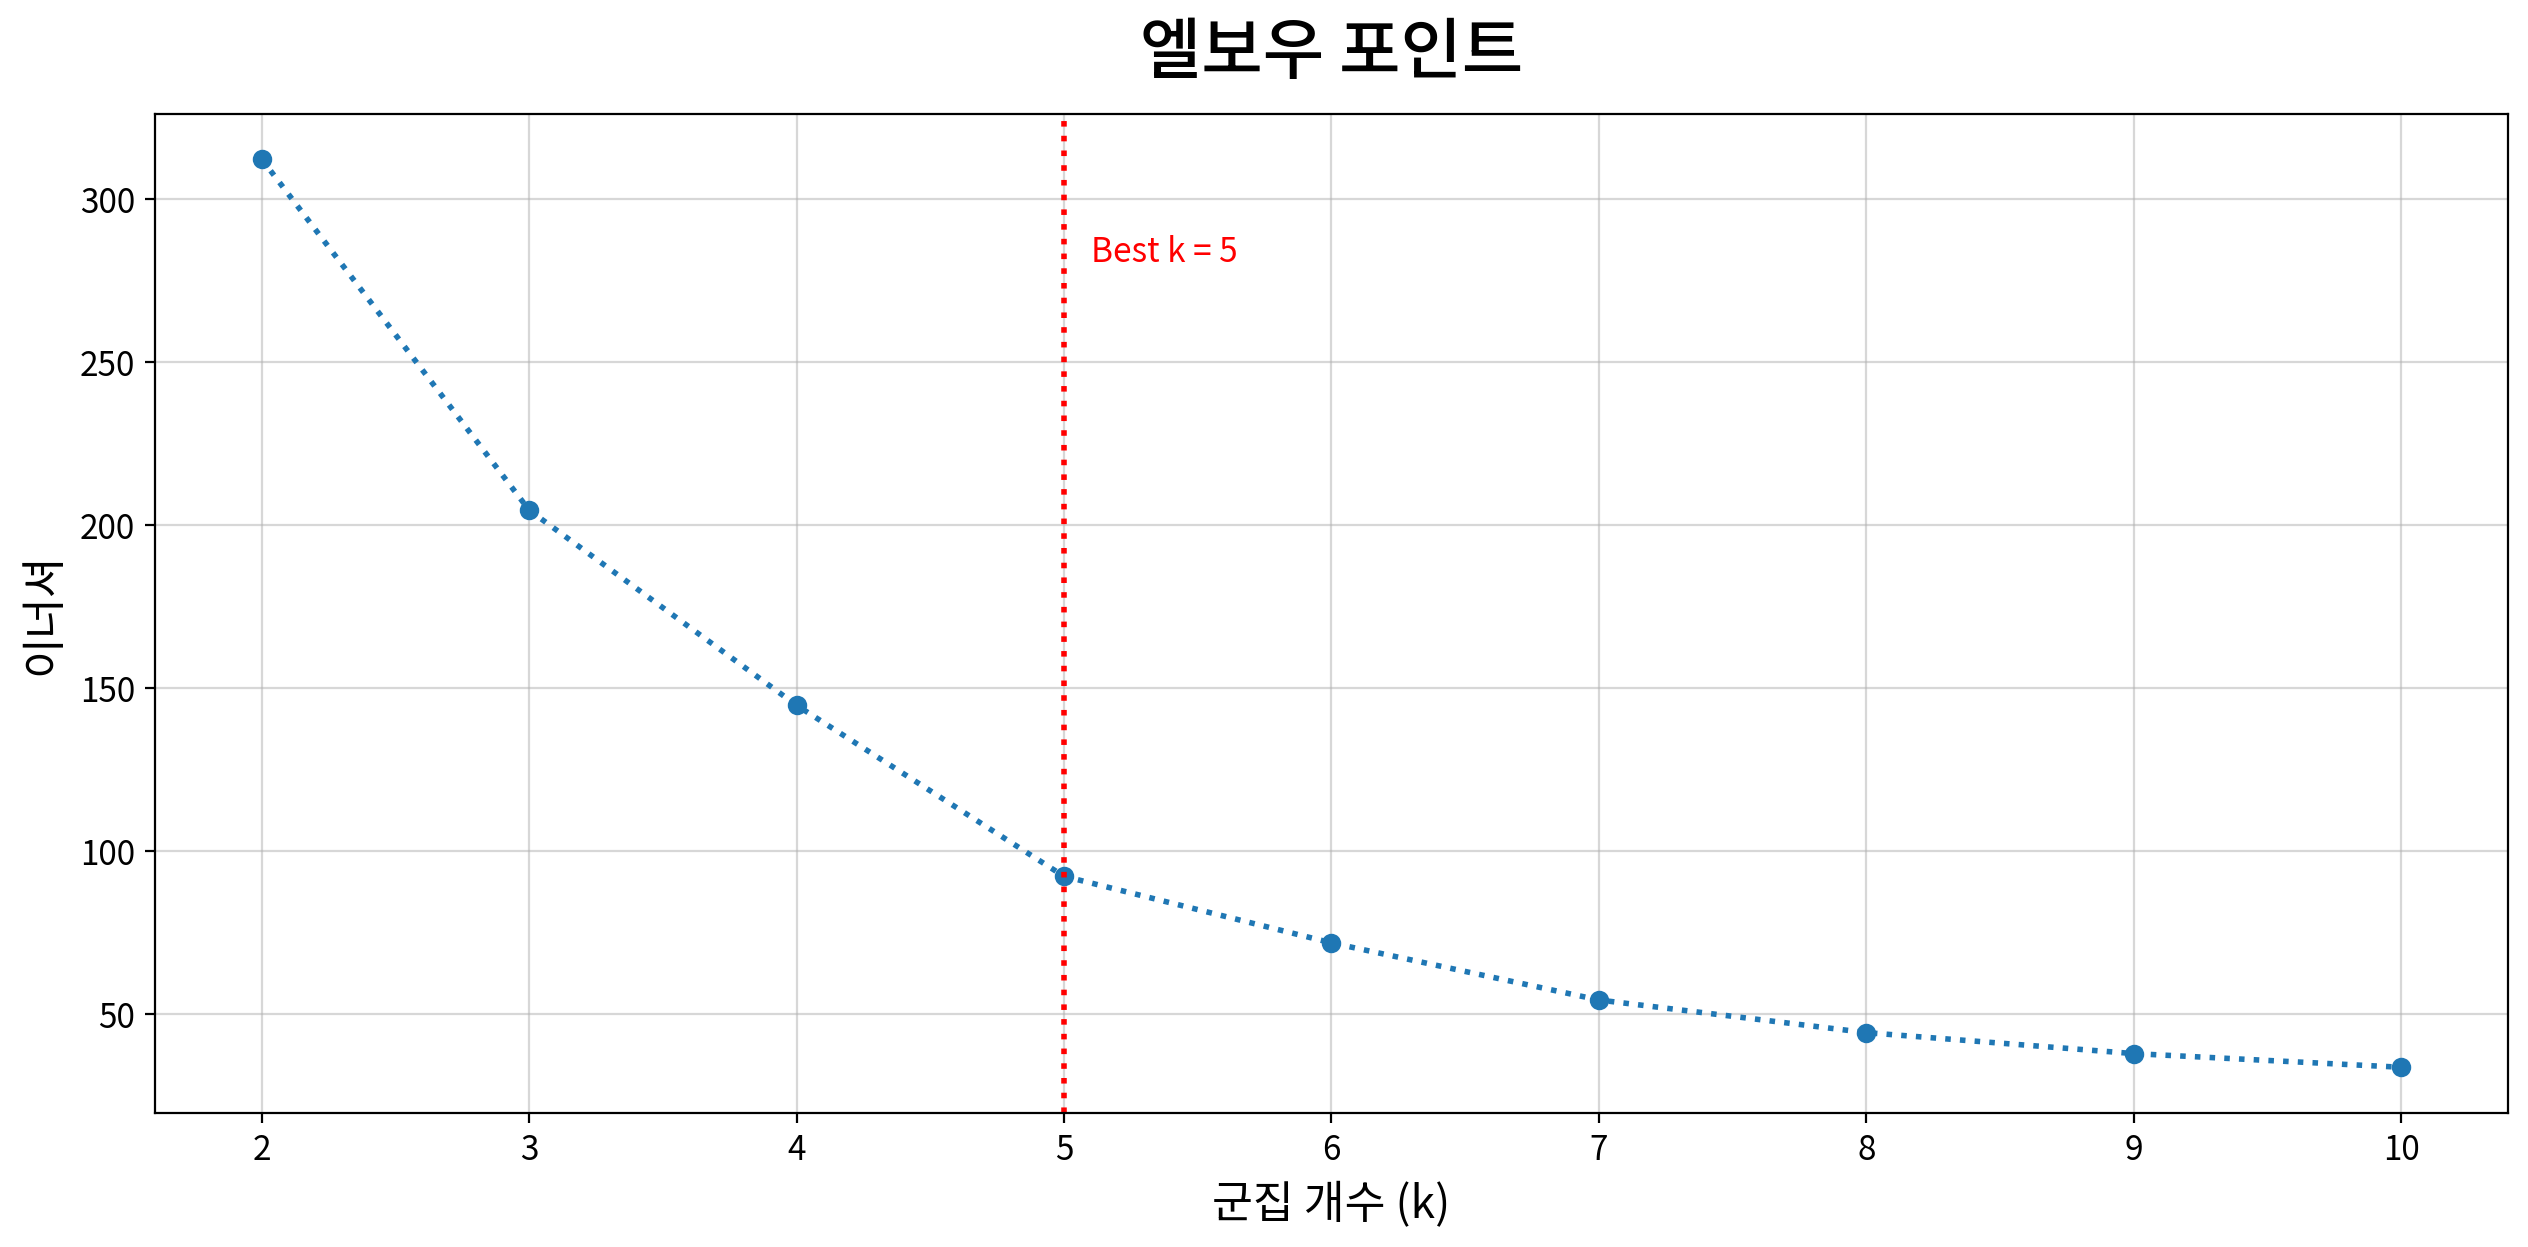

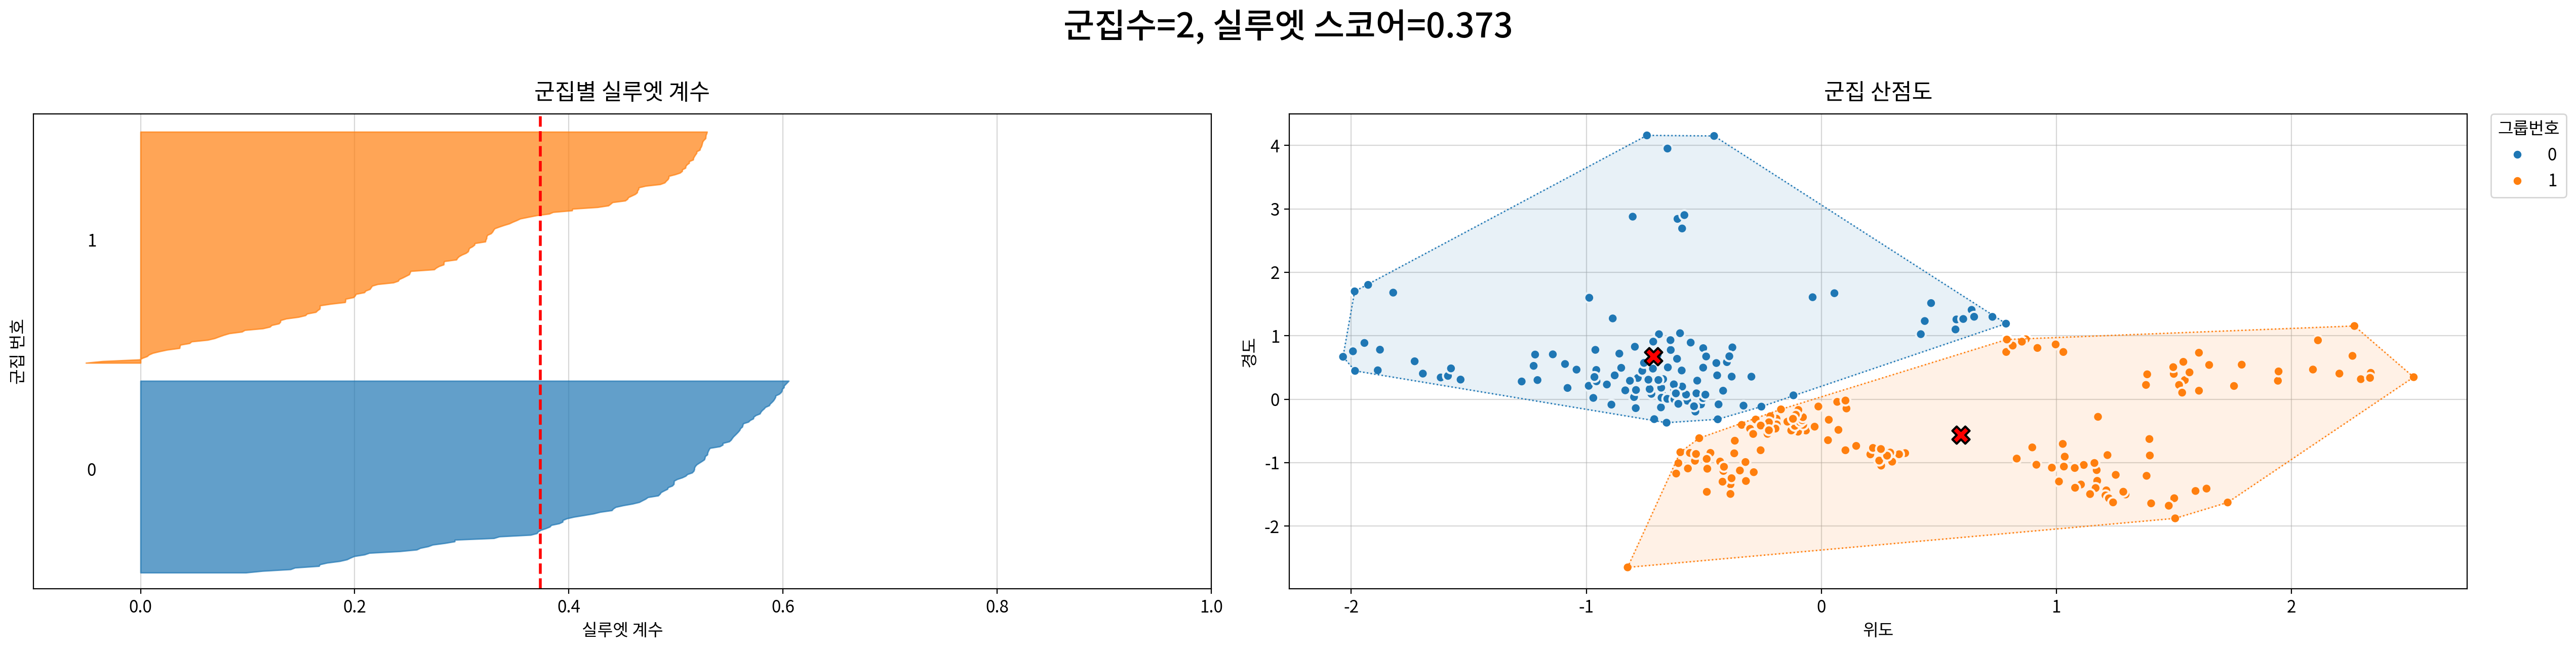

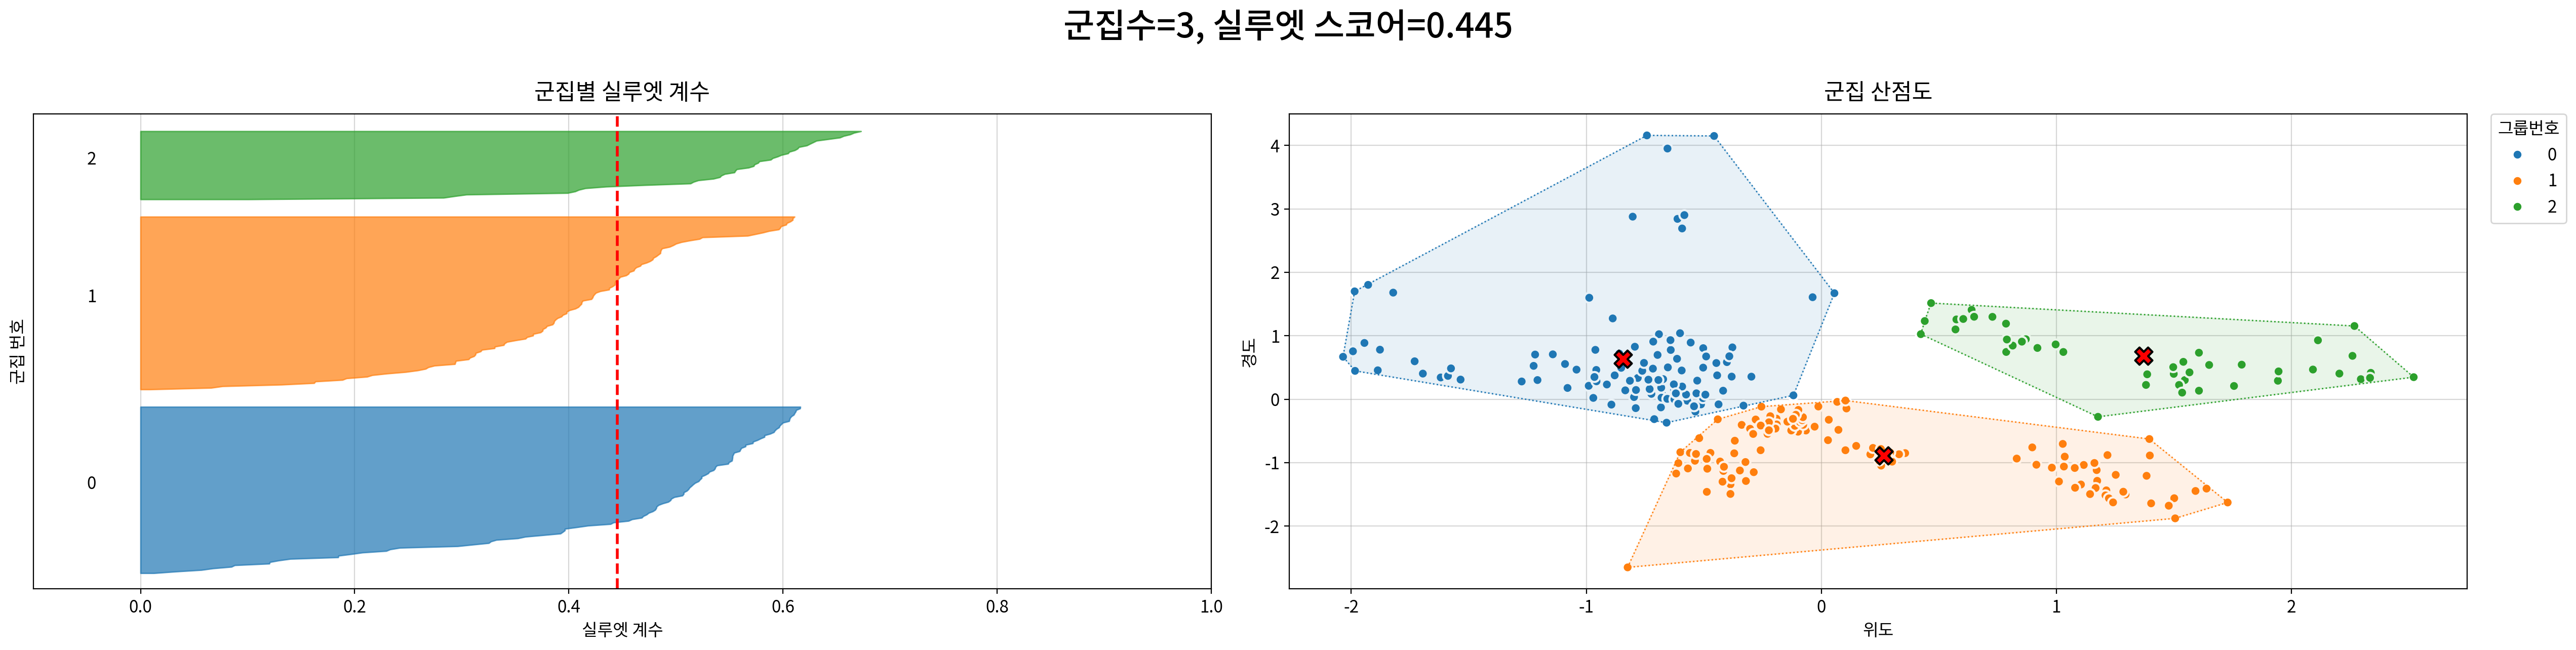

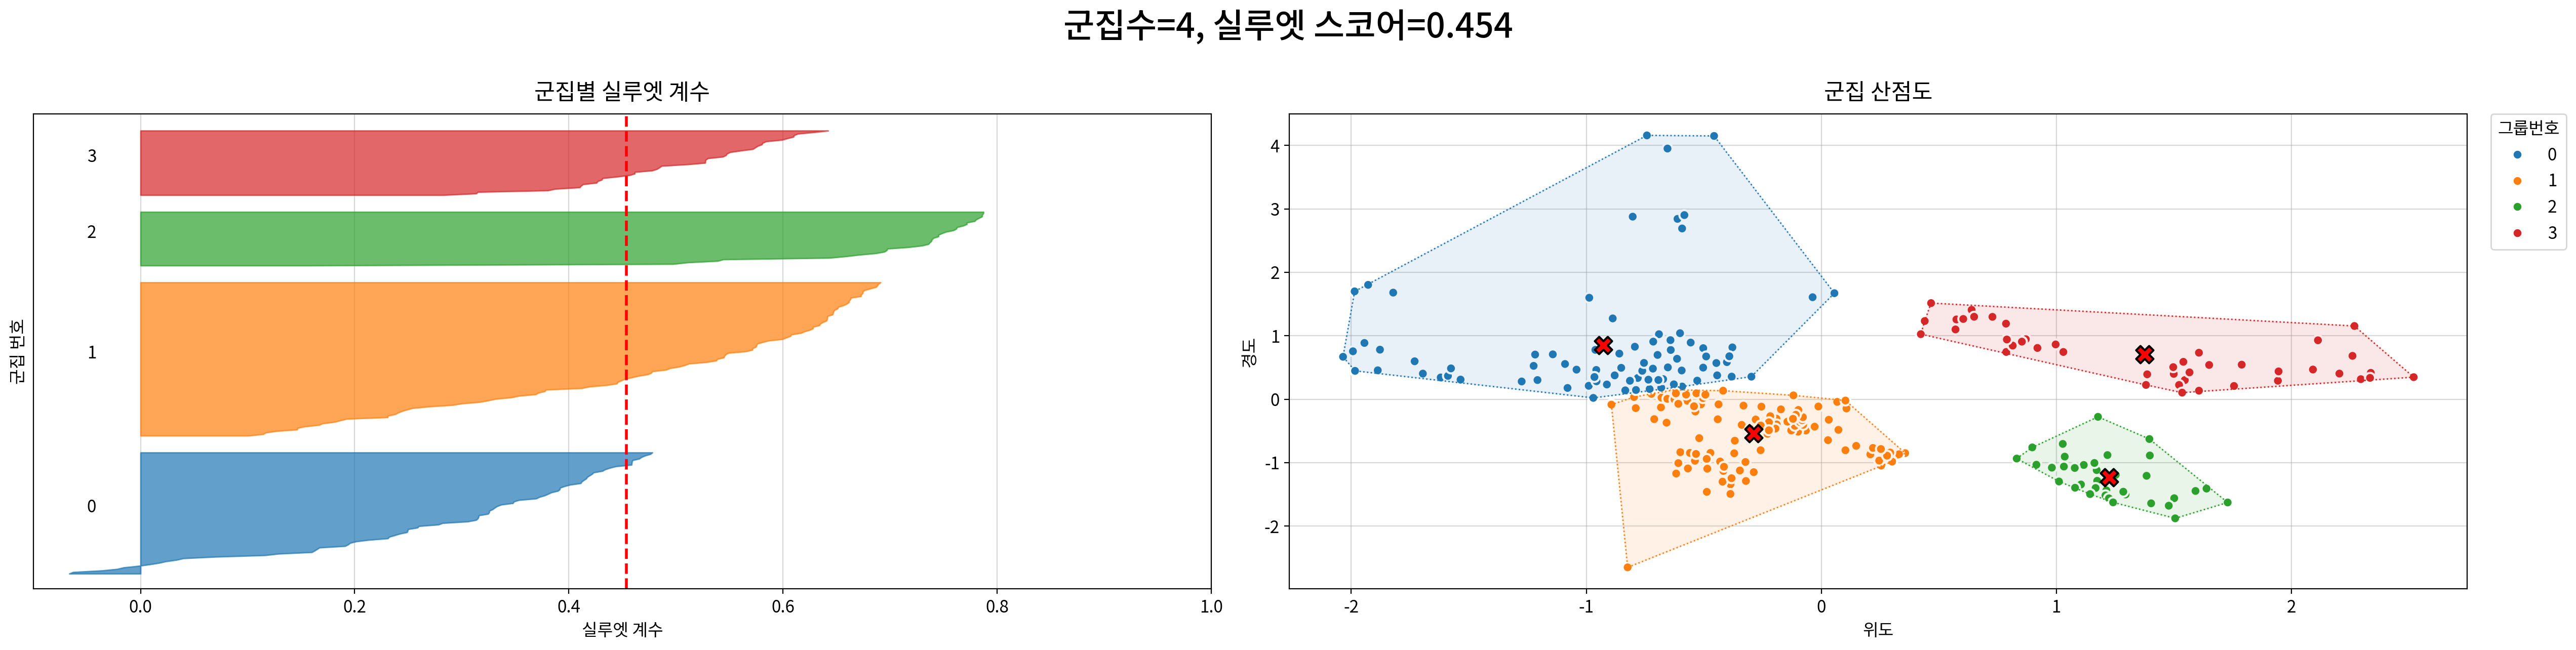

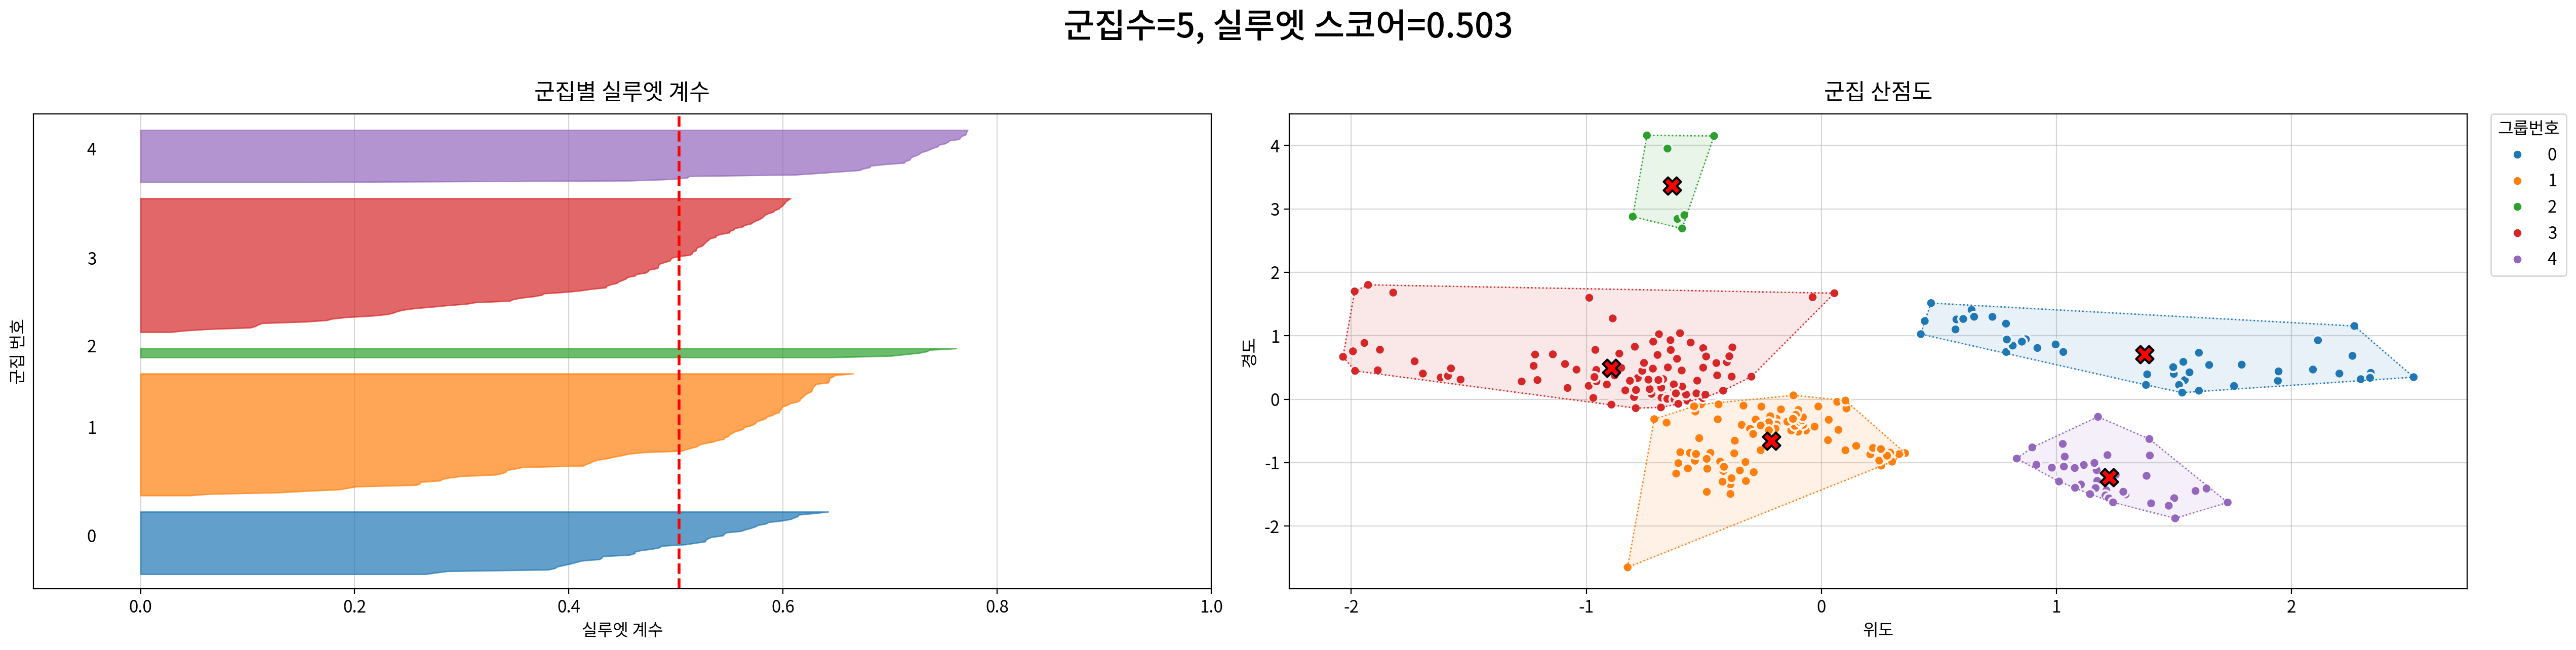

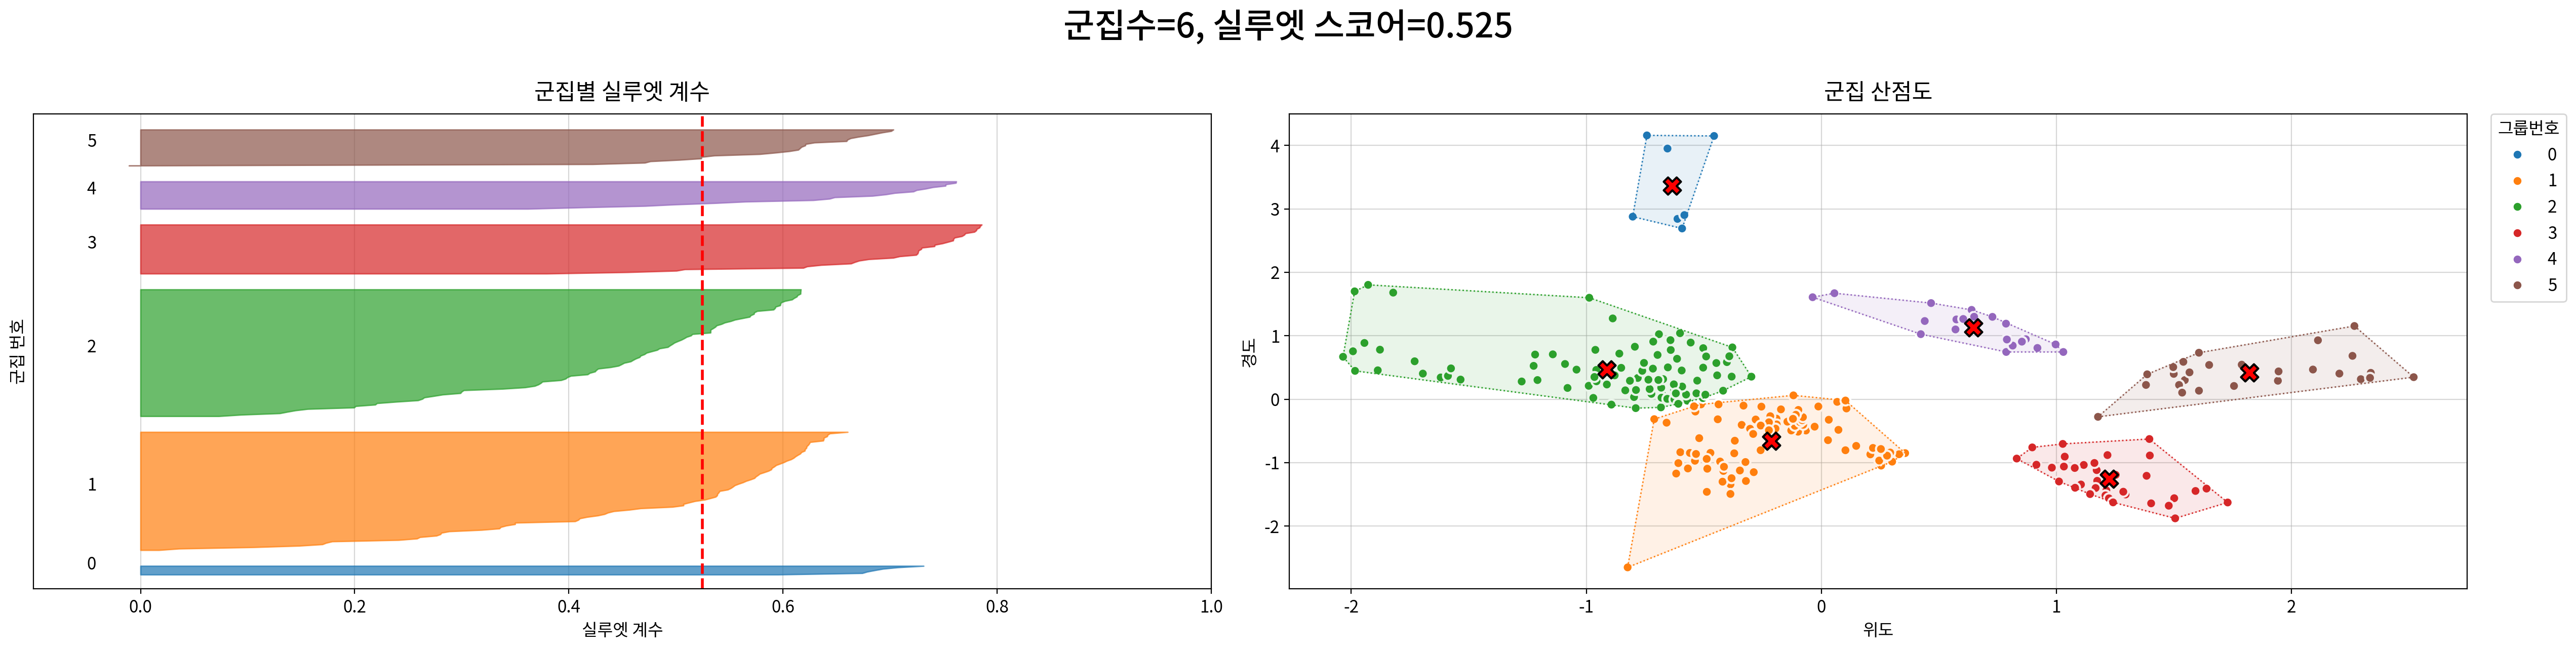

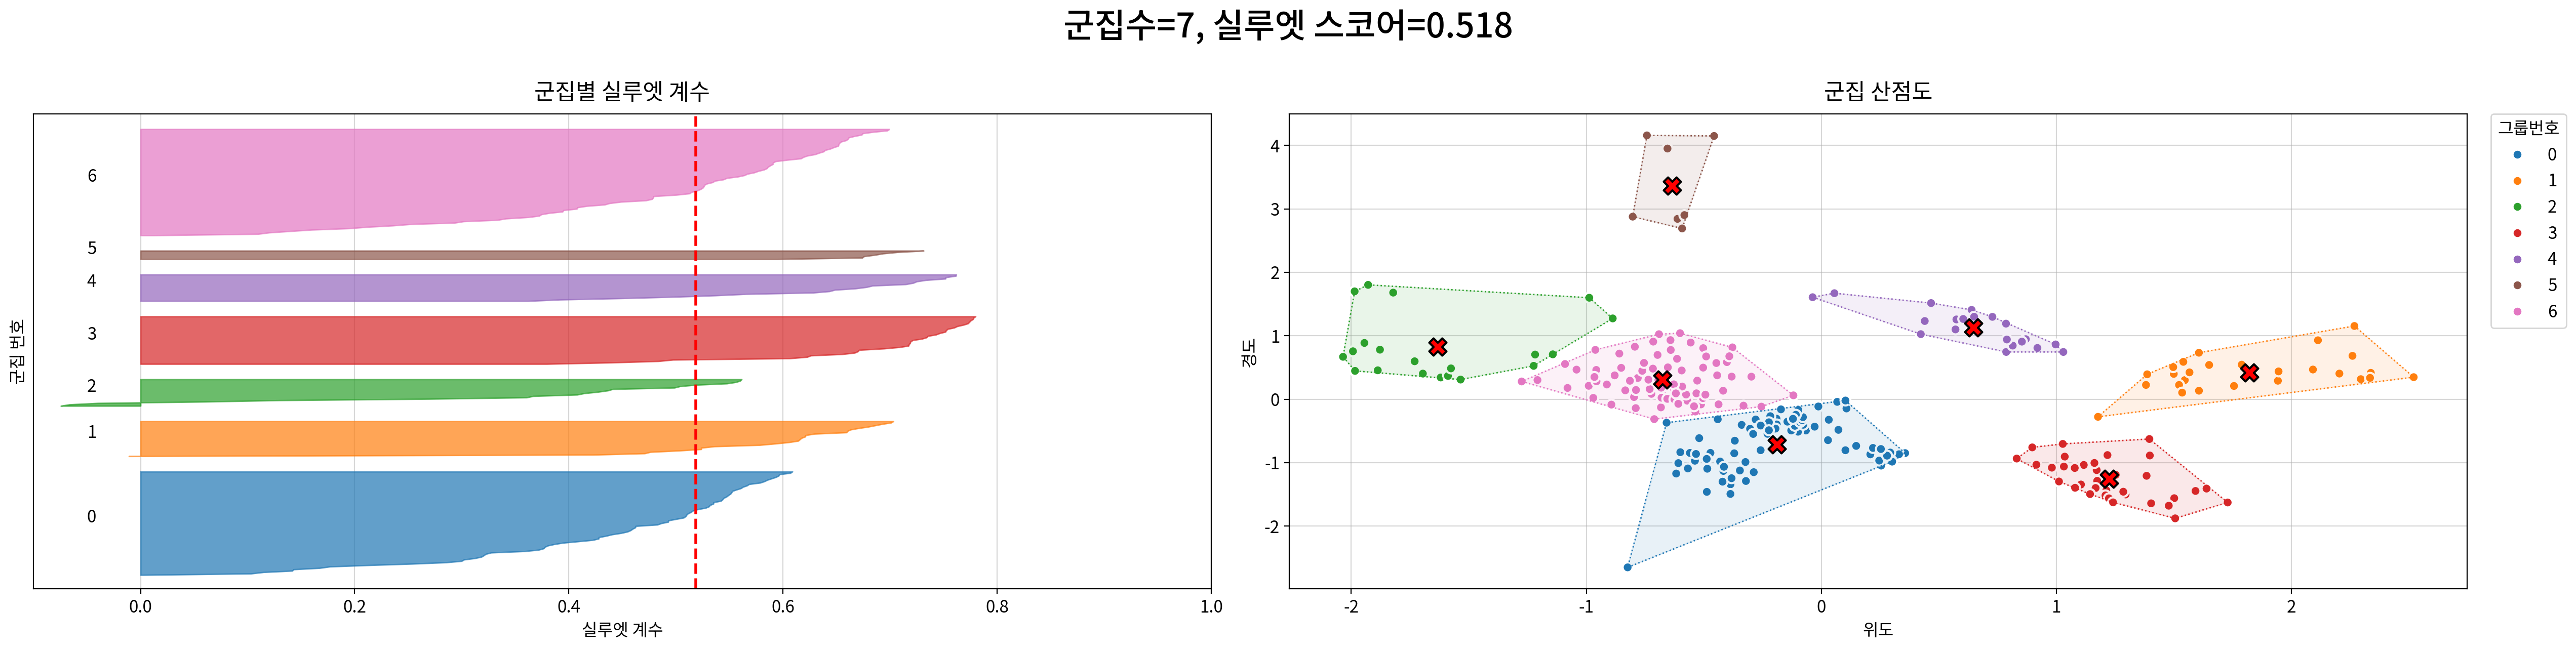

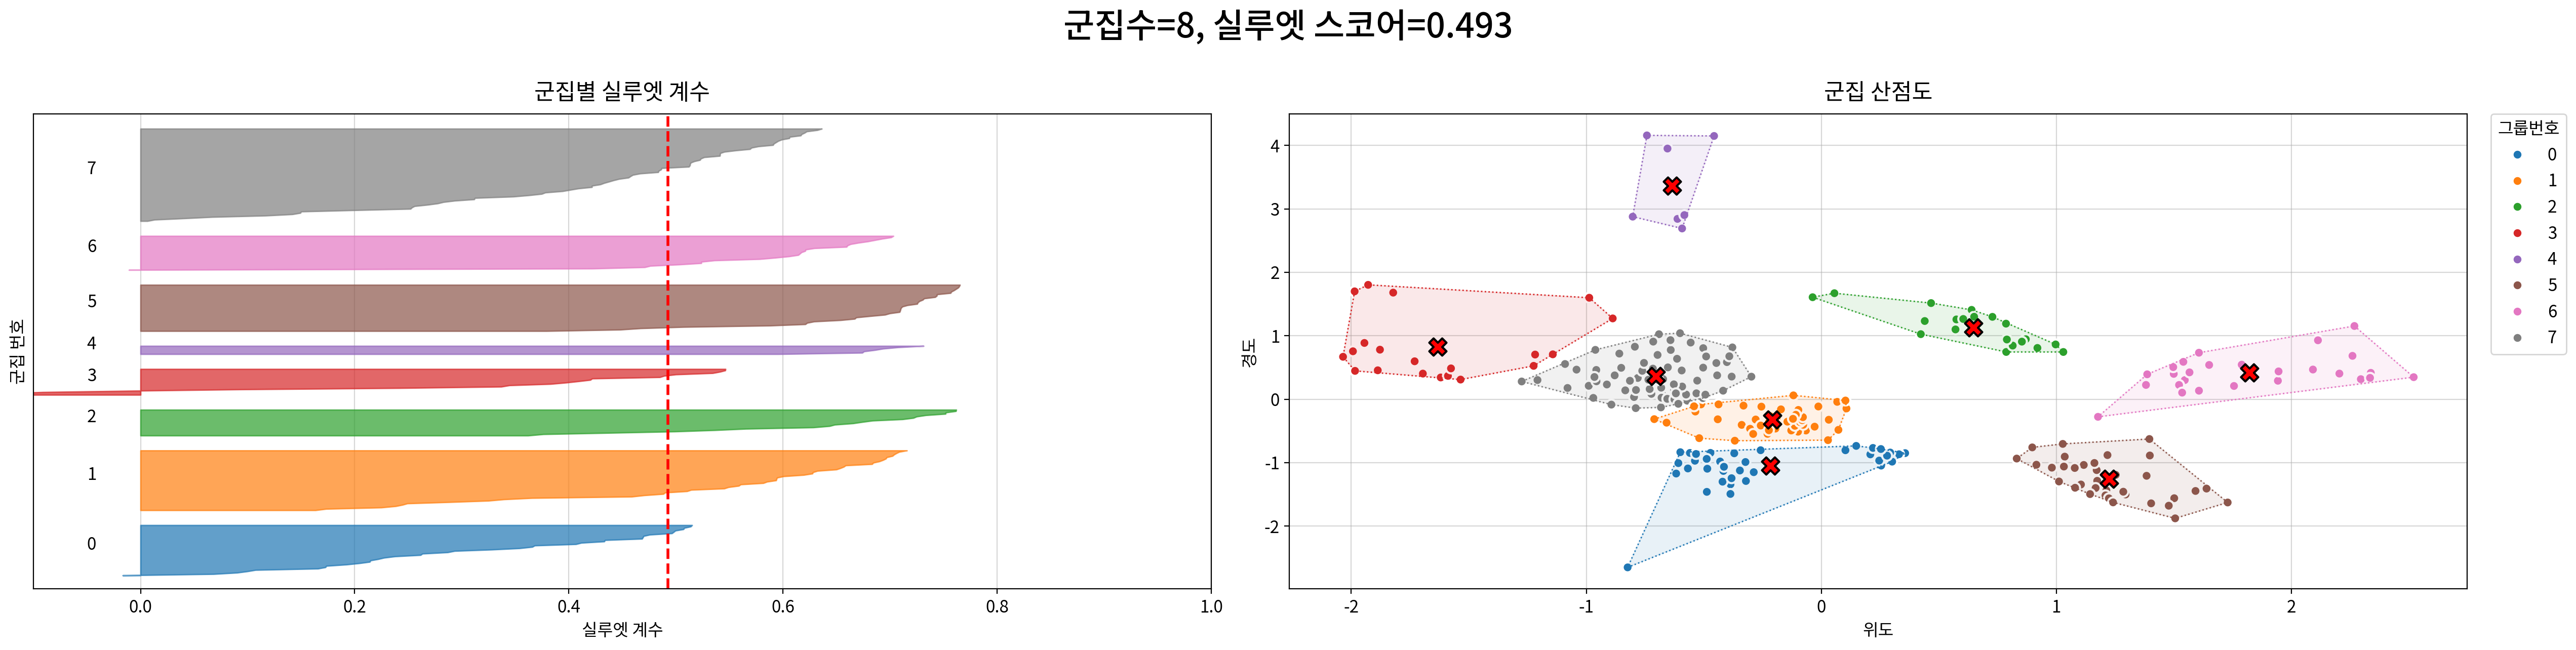

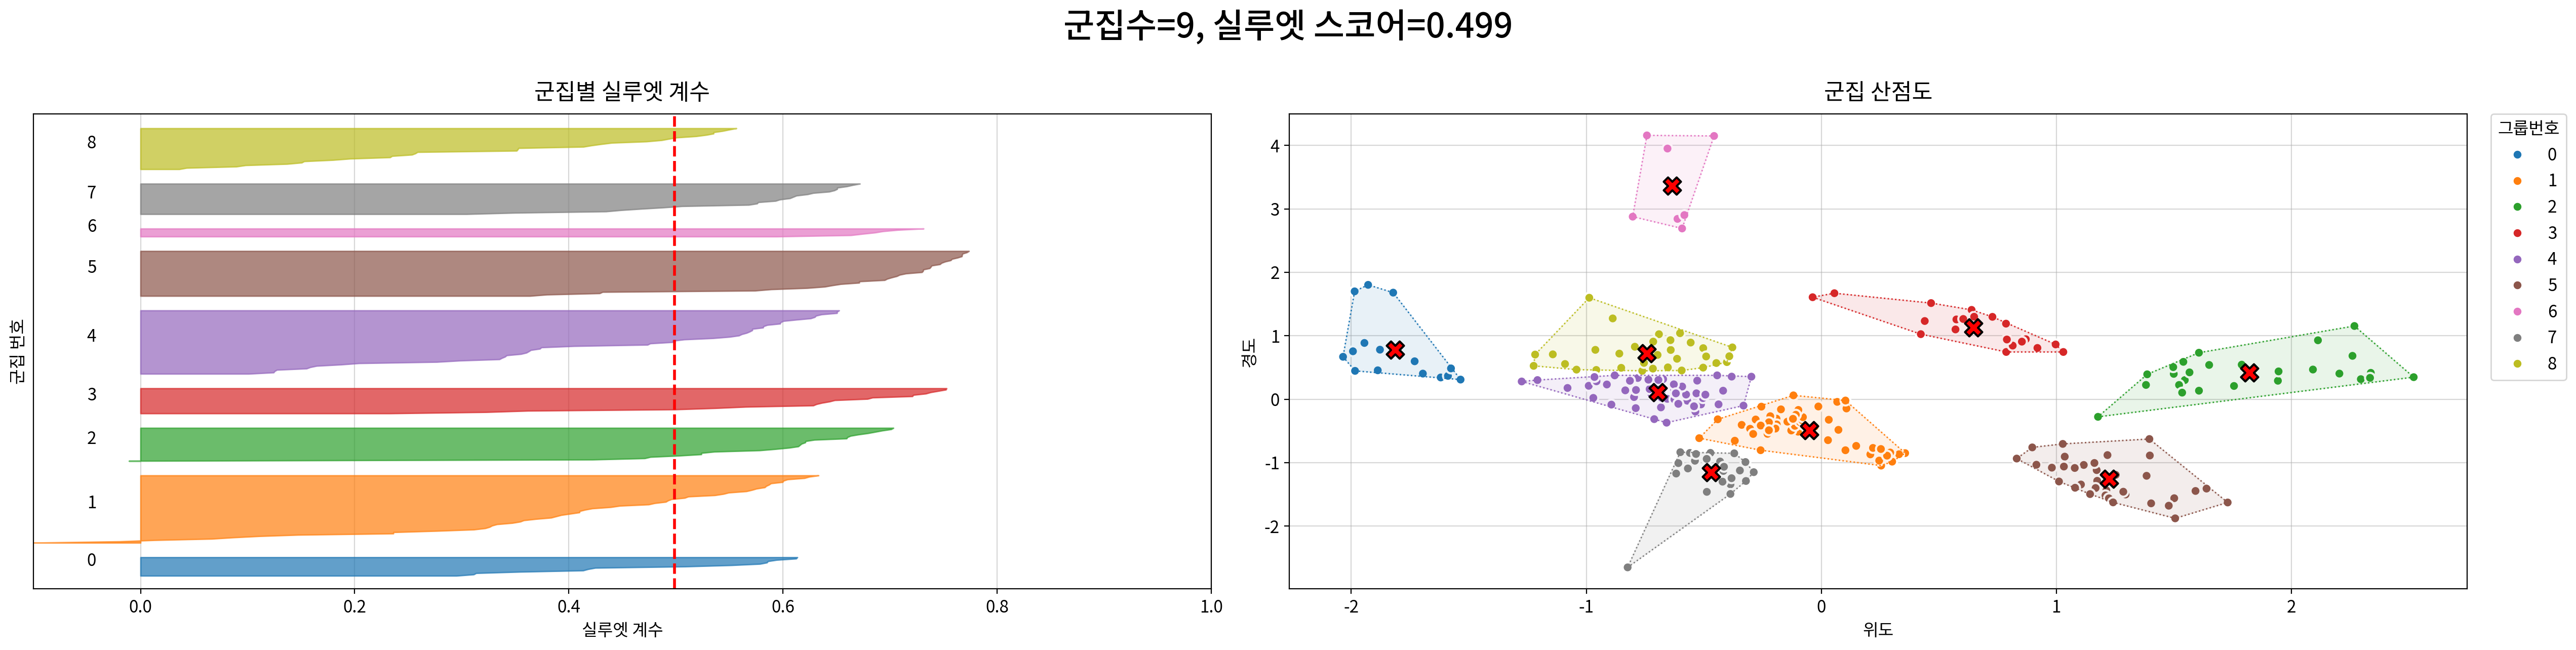

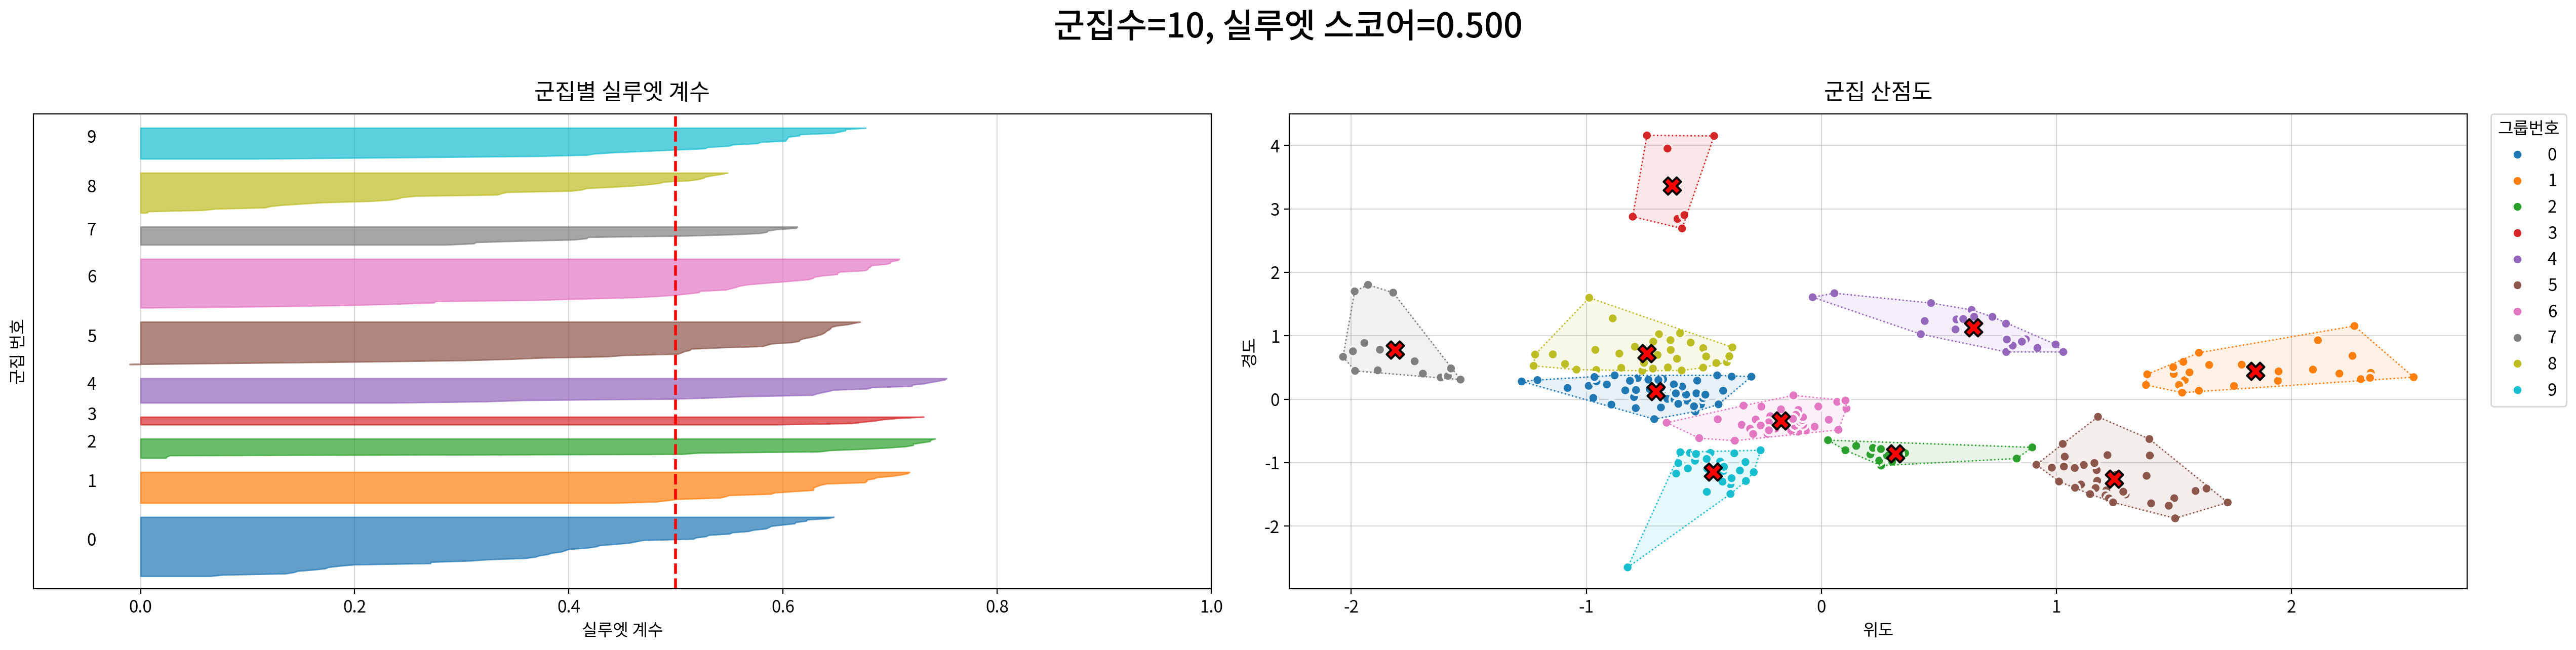

[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
 · k = 5 : 균형지수 0.0074 (스코어 0.5031, 두께비 13.0)
 · k = 2 : 균형지수 0.2757 (스코어 0.3735, 두께비 1.2034)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


(2,
     k       이너셔       감소량     스코어      전체면적      두께비  최소상대면적    균형지수
 0   2  312.1451       NaN  0.3735   97.1080   1.2034  0.8885  0.2757
 1   3  204.4943  107.6508  0.4451  115.7270   2.5000  0.6131  0.1092
 2   4  144.6364   59.8578  0.4537  117.9547   2.8056  0.7303  0.1181
 3   5   92.1925   52.4439  0.5031  130.8059  13.0000  0.1919  0.0074
 4   6   71.7704   20.4221  0.5247  136.4333  12.7143  0.2096  0.0087
 5   7   54.2563   17.5141  0.5185  134.8088  11.0000  0.2473  0.0117
 6   8   44.2436   10.0127  0.4926  128.0794   9.8571  0.2975  0.0149
 7   9   37.8112    6.4324  0.4989  129.7245   7.4286  0.3295  0.0221
 8  10   33.6191    4.1921  0.4996  129.8905   6.7143  0.3657  0.0272)

In [18]:
my_cluster.best_k(
    df_area,
    columns=["위도", "경도"],
    plot_each=True
)

In [19]:
final_k = 4

# 우편번호 70개 대신, 좌표 두 개로 4개 권역을 만든다.
estimator, cdf, _ = my_cluster.kmeans(df_area, k=final_k, columns=["위도", "경도"], plot=False)

df_area["spatial_cluster"] = cdf["그룹번호"].astype("category")
column_means["spatial_cluster"] = "위경도 기반 공간 군집"

# 권역별 규모 · 평균 가격 · 중심 좌표
display(df_area.groupby("spatial_cluster", observed=True).agg(
            평균매출=("평균매출", "mean"),
        ).sort_values("평균매출", ascending=False))

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
위도                 36.98 ~ 37.95          -2.04 ~ 2.52
경도               126.59 ~ 127.65          -2.65 ~ 4.16


,평균매출
spatial_cluster,
1,2.637219e+07
0,1.618534e+07
3,1.382024e+07
2,9.529920e+06


In [20]:
cluster_profile = df_area.groupby(
    "spatial_cluster", observed=True
).agg(
    행정동수=("행정동코드", "nunique"),
    가맹점수_소매=("가맹점수_소매", "mean"),
    가맹점수_음식=("가맹점수_음식", "mean"),
    총인구수=("총인구수", "mean"),
    만명당_가맹점수=("만명당_가맹점수", "mean"),
    인당_유동인구=("1인당_유동인구", "mean"),
    가맹점수_수리·개인=("가맹점수_수리·개인", "mean"),
)

display(cluster_profile.round(2))

,행정동수,가맹점수_소매,가맹점수_음식,총인구수,만명당_가맹점수,인당_유동인구,가맹점수_수리·개인
spatial_cluster,,,,,,,
0,80,246.68,316.06,30320.96,311.01,13.46,122.24
1,101,182.28,207.78,22409.26,294.57,33.46,80.49
2,36,197.95,251.04,27939.41,272.55,14.25,96.73
3,43,225.64,257.54,25131.38,345.31,11.81,102.07


In [21]:
df_area.groupby("spatial_cluster", observed=True).agg(
    행정동수=("행정동코드", "size"),
    평균=("평균매출", "mean"),
    중앙값=("평균매출", "median"),
    표준편차=("평균매출", "std"),
    최댓값=("평균매출", "max"),
).round(2)

,행정동수,평균,중앙값,표준편차,최댓값
spatial_cluster,,,,,
0,80,16185341.34,6955829.75,46720823.06,3.996625e+08
1,101,26372185.33,4113135.83,90693035.49,5.875862e+08
2,36,9529919.96,2745950.69,30011715.71,1.817880e+08
3,43,13820236.84,4030958.46,29791468.51,1.592371e+08


In [22]:
# 05. 공간특성 반영
## 3. 공간 특성 반영 파생변수 추가
target = "평균매출"
df_area["spatial_cluster"] = cdf["그룹번호"].astype("category")

# #02 와 같은 규칙으로 의미를 등록하고 목록 이름을 붙인다.
# -> #04의 검증 반복문이 이 이름을 그대로 받아 쓴다.
column_means["spatial_cluster"] = "위경도 기반 공간 군집"
spatial_cols = ["spatial_cluster"]

df_area[["spatial_cluster", "행정동코드"]].head()

,spatial_cluster,행정동코드
0,1,4111156000
1,1,4111156600
2,1,4111157100
3,1,4111157200
4,1,4111157300


In [23]:
# 06. 파생변수 검증
## 1. 검증 대상 분류

# 연속형 파생변수
# derived_continuous = ["sqft_per_bedroom", "living_ratio", "above_ratio", "living_vs_neighbor", "density_vs_neighbor"]

# 범주형 파생변수
derived_nominal = ["spatial_cluster"]

# print("연속형 파생 :", derived_continuous)
print("범주형 파생 :", derived_nominal)

범주형 파생 : ['spatial_cluster']


In [24]:
# 06. 파생변수 검증
## 3. 범주형 기술 통계량
df_area = my_qtcheck.set_type(df_area, as_category=derived_nominal)

derived_cat_desc = my_qtcheck.categorical_summary(df_area, columns=derived_nominal, value_counts=False)
derived_cat_desc

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   행정동코드            260 non-null    int64   
 1   행정구역             260 non-null    str     
 2   총인구수             260 non-null    float64 
 3   월유동인구수           260 non-null    float64 
 4   가맹점수_소매          260 non-null    float64 
 5   가맹점수_숙박          260 non-null    float64 
 6   가맹점수_음식          260 non-null    float64 
 7   가맹점수_부동산         260 non-null    float64 
 8   가맹점수_과학·기술       260 non-null    float64 
 9   가맹점수_시설관리·임대     260 non-null    float64 
 10  가맹점수_교육          260 non-null    float64 
 11  가맹점수_보건의료        260 non-null    float64 
 12  가맹점수_예술·스포츠      260 non-null    float64 
 13  가맹점수_수리·개인       260 non-null    float64 
 14  가맹점수_기타          260 non-null    float64 
 15  전체가맹점수           260 non-null    float64 
 16  소매_비율            260 non-null    float64 
 17  숙박_비율   

,spatial_cluster
count,260
unique,4
top,1
freq,101


In [25]:
# 06. 파생변수 검증
## 8. ANOVA (x: 3집단 이상 범주형 파생변수 -> y: 종속변수)
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df_area[n].unique()) >= 3:
        print()  # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶ {n}({column_means[n]}) → {target}"))

        # 분산분석
        display(my_stats.anova_oneway(df_area, y=target, between=n))

        # 사후검정
        display(my_stats.posthoc_oneway(df_area, y=target, between=n, plot=False))

#### ▶ spatial_cluster(위경도 기반 공간 군집) → 평균매출

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,spatial_cluster,3,256,0.842111,0.471895,0.009772,Negligible


비교한 조합 쌍: 6개
유의한 쌍: 0개
평균 차이가 가장 큰 쌍: (1) vs (2) → 차이 16842265.370, 효과크기 Small, p-value 0.535
평균 차이가 가장 작은 쌍: (0) vs (3) → 차이 2365104.501, 효과크기 Negligible, p-value 0.997


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,0,1,1.618534e+07,2.637219e+07,-1.018684e+07,9.647993e+06,-1.055851,0.716637,-0.136062,False,Negligible
1,Tukey HSD,0,2,1.618534e+07,9.529920e+06,6.655421e+06,1.293708e+07,0.514446,0.955591,0.156305,False,Negligible
2,Tukey HSD,0,3,1.618534e+07,1.382024e+07,2.365105e+06,1.218924e+07,0.194032,0.997406,0.056457,False,Negligible
3,Tukey HSD,1,2,2.637219e+07,9.529920e+06,1.684227e+07,1.251272e+07,1.346011,0.534516,0.210573,False,Small
4,Tukey HSD,1,3,2.637219e+07,1.382024e+07,1.255195e+07,1.173788e+07,1.069354,0.708512,0.160455,False,Negligible
5,Tukey HSD,2,3,9.529920e+06,1.382024e+07,-4.290317e+06,1.456235e+07,-0.294617,0.991085,-0.142126,False,Negligible


In [26]:
df_area.to_excel("local_data3.xlsx", index=False)